In [ ]:
import pandas as pd
import scanpy as sc
import os
import squidpy as sq
import re
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Not gzip-compatible; example in jupyterlab script
def load_vcf(file):
    if os.path.exists(file):
        
        # Load VCF results
        exclude = [i for i, line in enumerate(open(file)) if line.startswith('##')]
        if len(exclude)>0:
            skip_rows = max(exclude)+1
        else:
            skip_rows = None

        vcf = pd.read_csv(
            file,
            skiprows = skip_rows,
            sep = '\t')

        return vcf

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

def merge_granular_states(df, level_state, index_list=None):
    new_state_df = []
    for state in set(annotation_hierarchy[level_state]):
            cts_to_merge = annotation_hierarchy[annotation_hierarchy[level_state]==state]['annotation_granular'].tolist()
            cts_to_merge = [i for i in cts_to_merge if i in df.columns]
            if len(cts_to_merge)>0:
                if index_list is not None:
                    indices = [i for i in index_list if i in df.columns]
                    df = df.set_index(indices)
                col = df[cts_to_merge].sum(axis=1)
                col.name = state
                new_state_df.append(col)
    new_state_df = pd.concat(new_state_df, axis=1, ignore_index=False)
    return new_state_df

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, Future

# Load Visium data

In [ ]:
ROI_dir = '../data/annotated_anndata/'
visium_dir = '../../../data/GBM_LEAP_annotations/web_atlas/anndata/'
ROI_pass_dir = '../data/mutation_burden/'

visium_files = ['AT3-BRA5-FO-2_2.h5ad',
                'AT3-BRA5-FO-3_1.h5ad',
                'AT10-BRA-5-FO-1_2.h5ad',
                'AT10-BRA-5-FO-4_2.h5ad',
                'AT14-BRA-4-FO-2_1.h5ad']
ROI_dict = {
            'AT3-BRA5-FO-2_2.h5ad':'AT3-BRA5-FO-2-S26-B1',
            'AT3-BRA5-FO-3_1.h5ad':'AT3-BRA5-FO-3-S20-A1',
            'AT10-BRA-5-FO-1_2.h5ad':'AT10-BRA-5-FO-1-S21-b',
            'AT10-BRA-5-FO-4_2.h5ad':'AT10-BRA-5-FO-4-S22',
            'AT14-BRA-4-FO-2_1.h5ad':'AT14-BRA-4-FO-2-S18'
}

annotation_hierarchy = pd.read_csv('/../../../data/GBM_LEAP_annotations/annotation_hierarchy.tsv', 
                                   sep = '\t')
annotation_hierarchy['annotation_granular'] = np.where(
    annotation_hierarchy['annotation_granular']=='Hypoxic 1', 'Hypoxic 1 (cell state)', 
    annotation_hierarchy['annotation_granular'])
annotation_hierarchy['annotation_granular'] = np.where(
    annotation_hierarchy['annotation_granular']=='Hypoxic 2', 'Hypoxic 2 (cell state)', 
    annotation_hierarchy['annotation_granular'] )

sex_assignment = {
    'PD63564': 'XX',
    'PD60967': 'XY',
    'PD60966': 'XY'
}

In [ ]:
registration=False

slides = {}
ROI_map = []
for visium_file in visium_files:

    # ROI information
    ROIs = pd.read_csv(ROI_dir+ROI_dict[visium_file]+'.csv') # main transfer df
    if visium_file=='AT3-BRA5-FO-2_2.h5ad':
        ROIs['F1'] = ROIs['LCM_F1'].copy() # error in original transfer
    ROI_passed = pd.read_csv(ROI_pass_dir+'ROI_passed.tsv', sep = '\t') # metadata
    ROI_passed = ROI_passed[ROI_passed['section_id']==ROI_dict[visium_file]]

    if registration==True:
        if 'AT14' not in visium_file:
            ROI_list = [i for i in ROIs.columns if 'LCM' in i]
            ROI_passed['well_id'] = ['LCM_'+i for i in ROI_passed['well_id']]
        else:
            ROI_list = [i for i in ROIs.columns if re.search(r'[A-Z][0-9]{1,2}', i)]
    else:
        ROI_list = [i for i in ROI_passed['well_id'].tolist() if i in ROIs.columns]

    ROI_map.append(ROI_passed)

    # load cell2loc adata and merge ROI metadata
    adata = sc.read_h5ad(visium_dir+visium_file)
    adata.obs['barcode'] = [re.sub('_.*$', '', i) for i in adata.obs.index.tolist()]
    adata.obs = adata.obs.reset_index().merge(ROIs, on = 'barcode', how = 'left').set_index('index')

    adata.obs['ROI_IDs'] = adata.obs[ROI_list].idxmax(axis=1)
    adata.obs['ROI_IDs'] = np.where(adata.obs[ROI_list].sum(axis=1)==0, np.nan, adata.obs['ROI_IDs'])

    # calculate cell state abundances
    ROI_ct_abundances = []
    for ROI in ROI_list:
        abundance_df = pd.DataFrame(adata[:,adata.var['feature_types']=='Cell state abundances'].X.toarray())
        abundance_df.columns = adata[:,adata.var['feature_types']=='Cell state abundances'].var.index.tolist()
        abundance_df.index = adata.obs.index

        series = abundance_df.mul(adata.obs[ROI], axis=0).sum() # >0 means if presence; include
        series.name = ROI
        ROI_ct_abundances.append(series)
        
    ROI_ct_abundances = pd.concat(ROI_ct_abundances, axis=1)
    ROI_ct_abundances = ROI_ct_abundances.loc[:,ROI_ct_abundances.sum()>0] # filter bad ROIs

    adata.obs = adata.obs.reset_index().merge(ROI_passed.rename(columns={'well_id':'ROI_IDs',
                                    'index':'PDID'}), on = 'ROI_IDs', how = 'left').set_index('index')

    slides[visium_file] = adata
ROI_map = pd.concat(ROI_map)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/annd

# Load SpaceTree data

In [ ]:
spacetree_dir = '../../../data/GBM_LEAP_annotations/spacetree_new/'

spacetree_files = {'AT3':
{'visium_annotated_spaceranger130_count_45132_GBM_SPA12928178_GRCh38-2020-A.h5ad':'AT3-BRA5-FO-3_1.h5ad',
 'visium_annotated_spaceranger130_count_45272_GBM_SPA12944635_GRCh38-2020-A.h5ad':'AT3-BRA5-FO-2_2.h5ad'}
}

clone_dict = {
'AT3': ['0', '1', '2', '3', '4'],
'AT10': ['0', '1', '2', '3', '4']
}

for section in slides:
    for i in range(11):
        if str(i) in slides[section].obs.columns:
            del(slides[section].obs[str(i)])

In [ ]:
for donor in spacetree_files:
    for file in spacetree_files[donor]:

        adata = sc.read_h5ad(spacetree_dir+file)
        adata.obs['barcodes'] = [re.sub('^.*_', '', i) for i in adata.obs.index]
        adata.obs['spaceranger_id']  = [re.sub('A_.*$', 'A', i) for i in adata.obs.index]
        adata.obs.index = adata.obs['barcodes']+'_'+adata.obs['spaceranger_id']

        if clone_dict[donor][0] not in slides[spacetree_files[donor][file]].obs.columns:
            slides[spacetree_files[donor][file]].obs = slides[spacetree_files[donor][file]].obs.reset_index().merge(
                adata.obs[clone_dict[donor]].reset_index(),
                on = 'index', how = 'left').set_index('index')

# Load pairtree data

In [ ]:
donor_dict = {'AT3':'PD60967'}
wd = '../data/LCM_analysis/'

pairtree_output = {}
for donor in donor_dict:
    with open(wd+'pyclone_vi/{}.json'.format(donor_dict[donor])) as f:
        tree_json = json.load(f)
        pairtree_output[donor] = pd.DataFrame(tree_json['eta'], columns = tree_json['samples']).transpose()

# Hierarchical clustering (AT3)

In [ ]:
donor = 'AT3'
sections = [i for i in slides if donor in i]

pt_df = pairtree_output[donor].copy()

## Pyclone - pairtree

In [ ]:
from sklearn.metrics import pairwise_distances, silhouette_score

# Get optimal k
D = pairwise_distances(pt_df, metric="braycurtis")  # Bray–Curtis in sklearn
best = max(
    ((k,
      silhouette_score(D,
                       AgglomerativeClustering(n_clusters=k, linkage="average",
                                               metric="precomputed").fit_predict(D),
                       metric="precomputed"))
     for k in range(2, 15)),
    key=lambda x: x[1]
)
k_star, sil = best

In [ ]:
# cluster
cluster = AgglomerativeClustering(n_clusters=k_star, 
                                  metric = 'braycurtis',
                                  linkage='complete', 
                                  compute_full_tree=True)

# Cluster the data
cluster_labels = cluster.fit_predict(pt_df)

In [ ]:
# cluster df
pt_df['cluster'] = cluster_labels
pt_cluster_ids = pt_df.reset_index().sort_values('cluster')\
    [['index','cluster']].rename(columns={'index':'PDID'})\
    .reset_index(drop=True)
pt_df = pt_df.drop('cluster', axis=1)

# check
pt_clustered = pt_df.transpose()[pt_cluster_ids['PDID']]
sns.heatmap(pt_clustered, cmap = 'Reds')
plt.show()

In [ ]:
pt_cluster_ids.to_csv('../data/LCM_ST_comparison/AT3/AT3_PT_labels.csv')

## SpaceTree

In [ ]:
st_df = []
for section in sections:
    clones = [i for i in clone_dict[donor] if i in slides[section].obs.columns]
    df = slides[section].obs[clones+['PDID']]
    df = slides[section].obs[clones+['PDID']].dropna()
    df = df.groupby('PDID')[clones].sum()
    df = df.divide(df.sum(axis=1), axis=0)
    st_df.append(df)
st_df = pd.concat(st_df).fillna(0)


In [ ]:
from sklearn.metrics import pairwise_distances, silhouette_score

D = pairwise_distances(st_df, metric="braycurtis")  # Bray–Curtis in sklearn
best = max(
    ((k,
      silhouette_score(D,
                       AgglomerativeClustering(n_clusters=k, linkage="average",
                                               metric="precomputed").fit_predict(D),
                       metric="precomputed"))
     for k in range(3, 15)),
    key=lambda x: x[1]
)
k_star, sil = best

In [ ]:
# cluster
cluster = AgglomerativeClustering(n_clusters=k_star, 
                                  metric = 'braycurtis',
                                  linkage='complete', 
                                  compute_full_tree=True)

# Cluster the data
cluster_labels = cluster.fit_predict(st_df)

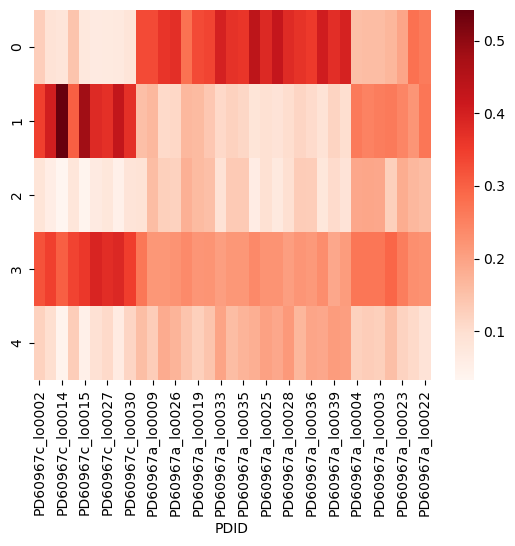

In [ ]:
# cluster df
st_df['cluster'] = cluster_labels
st_cluster_ids = st_df.reset_index().sort_values('cluster')[['PDID','cluster']].reset_index(drop=True)
st_df = st_df.drop('cluster', axis=1)

# check
st_clustered = st_df.transpose()[st_cluster_ids['PDID']]
sns.heatmap(st_clustered, cmap = 'Reds')
plt.show()

In [ ]:
st_cluster_ids.to_csv('../data/LCM_ST_comparison/AT3/AT3_ST_labels.csv')

## Comparison

In [ ]:
pt_cluster_ids = pd.read_csv('../data/LCM_ST_comparison/AT3/AT3_PT_labels.csv', index_col=0)
st_cluster_ids = pd.read_csv('../data/LCM_ST_comparison/AT3/AT3_ST_labels.csv', index_col=0)

In [ ]:
pt_st_comparison = pt_cluster_ids.merge(st_cluster_ids, on = 'PDID', suffixes = ['_pt', '_st'])\
    .sort_values('cluster_st')
pt_st_comparison['cluster_pt'] = ['LCM: '+str(i) for i in pt_st_comparison['cluster_pt']]
pt_st_comparison['cluster_st'] = ['ST: '+str(i) for i in pt_st_comparison['cluster_st']]

for section in slides:
    if donor in section:
        if 'cluster_pt' not in slides[section].obs.columns:
            slides[section].obs = slides[section].obs.merge(pt_st_comparison, on = 'PDID', how = 'left')

In [ ]:
pt_st_comparison.sort_values('cluster_pt').style.hide()

In [ ]:
pt_st_comparison.to_csv('../../../data/EDFig5/EDFig5g.csv')

## Alluvial/Sankey

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from io import StringIO
import re

def _hex_to_rgba(c, alpha=0.5):
    """
    Convert HEX ('#AABBCC' or 'AABBCC') or rgb/rgba string/tuple to an rgba() string.
    If c is already rgba(), its alpha is overridden by `alpha` if provided.
    """
    if isinstance(c, tuple) and (3 <= len(c) <= 4):  # (r,g,b[,a])
        r, g, b = c[:3]
        a = c[3] if len(c) == 4 else alpha
        return f"rgba({int(r)},{int(g)},{int(b)},{float(a)})"
    if isinstance(c, str):
        c = c.strip()
        if c.lower().startswith("rgba"):
            if alpha is None:
                return c
            nums = re.findall(r"[\d.]+", c)
            if len(nums) >= 3:
                return f"rgba({nums[0]},{nums[1]},{nums[2]},{alpha})"
            return c
        if c.lower().startswith("rgb"):
            nums = re.findall(r"\d+", c)
            if len(nums) >= 3:
                return f"rgba({nums[0]},{nums[1]},{nums[2]},{alpha if alpha is not None else 1})"
            return c
        c = c[1:] if c.startswith("#") else c  # HEX
        if len(c) == 3:
            c = "".join([ch * 2 for ch in c])
        if len(c) == 6:
            r = int(c[0:2], 16)
            g = int(c[2:4], 16)
            b = int(c[4:6], 16)
            return f"rgba({r},{g},{b},{alpha if alpha is not None else 1})"
    return "rgba(150,150,150,0.5)"  # fallback

def make_alluvial(
    df: pd.DataFrame,
    left_col: str = "cluster_1",
    right_col: str = "cluster_2",
    sample_col: str = "sample",
    node_color_map: dict | None = None,
    link_color_map: dict | None = None,
    link_alpha: float = 0.8,
    title: str | None = None,
) -> go.Figure:
    """
    Build a Plotly Sankey (alluvial) diagram from a long-form dataframe with one row per sample.

    Parameters
    ----------
    df : DataFrame with at least [sample_col, left_col, right_col].
         Each row is counted as weight=1 toward the flow from left_col -> right_col.
    left_col, right_col : columns representing the two cluster assignments.
    sample_col : name of the sample column (used only for labeling).
    node_color_map : dict mapping node labels to colors, e.g.,
                     {'cluster_1: 2': '#1f77b4', 'cluster_2: 0': '#ff7f0e'}.
    link_color_map : dict mapping *left-side node labels* to colors applied to all links
                     leaving that node. Keys look like 'cluster_1: 2'. If None, links inherit
                     the left-node color with transparency.
    link_alpha : transparency (0..1) used when deriving link colors from node colors.
    title : optional figure title.

    Returns
    -------
    fig : plotly.graph_objects.Figure
    """
    df = df.copy()
    df[left_col] = df[left_col].astype(str)
    df[right_col] = df[right_col].astype(str)

    # Count flows (each sample = 1)
    flows = (
        df.groupby([left_col, right_col], as_index=False)
          .size()
          .rename(columns={"size": "value"})
    )

    # Build node labels (prefix with column names to disambiguate '0', '1', etc.)
    left_vals = sorted(df[left_col].unique(), key=lambda x: (len(x), x))
    right_vals = sorted(df[right_col].unique(), key=lambda x: (len(x), x))

    left_labels = [v for v in left_vals]
    right_labels = [v for v in right_vals]
    node_labels = left_labels + right_labels

    # Index maps
    left_index = {v: i for i, v in enumerate(left_vals)}
    right_index = {v: i for i, v in enumerate(right_vals)}

    # Sources/targets/values (+ text for hover)
    sources, targets, values, hover_s, hover_t = [], [], [], [], []
    for _, row in flows.iterrows():
        lv, rv, val = row[left_col], row[right_col], int(row["value"])
        s_idx = left_index[lv]
        t_idx = len(left_labels) + right_index[rv]
        sources.append(s_idx)
        targets.append(t_idx)
        values.append(val)
        hover_s.append(lv)
        hover_t.append(rv)

    # Node colors
    node_color_map = node_color_map or {}
    node_colors = [node_color_map.get(label, "#C7C7C7") for label in node_labels]

    # Link colors (inherit left-node color unless map provided)
    link_colors = []
    for s_idx, s_lab in zip(sources, hover_s):
        if link_color_map and s_lab in link_color_map:
            c = _hex_to_rgba(link_color_map[s_lab], link_alpha)
        else:
            base = node_color_map.get(node_labels[s_idx], "#C7C7C7")
            c = _hex_to_rgba(base, link_alpha)
        link_colors.append(c)

    # Custom hover for links
    link_hover = [f"{s} → {t}<br>count: {v}" for s, t, v in zip(hover_s, hover_t, values)]

    sankey = go.Sankey(
        arrangement="snap",
        node=dict(
            label=node_labels,
            color=node_colors,
            pad=20,
            thickness=24,
            hovertemplate="%{label}<extra></extra>",
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            customdata=link_hover,
            hovertemplate="%{customdata}<extra></extra>",
        ),
    )
    fig = go.Figure(sankey)
    fig.update_layout(
        title=title or f"Alluvial flow: {left_col} → {right_col} (weighted by {sample_col} count)",
        font=dict(size=13),
        margin=dict(l=10, r=10, t=40, b=10),
        height=500,
    )
    return fig

In [ ]:
from pylab import *

cmap = cm.get_cmap('tab10', 10)

# node colour map
clusters = sorted(set(pt_st_comparison['cluster_pt']))+sorted(set(pt_st_comparison['cluster_st']))
node_color_map = {}
for i in range(len(clusters)):
    cluster = clusters[i]
    rgba = cmap(i)
    node_color_map[cluster] = matplotlib.colors.rgb2hex(rgba)

# link/ribbon colour map
link_color_map = {
'LCM: 1':'#8B000B', 
'LCM: 2':'#8B000B', 
'LCM: 6':'#8B000B',
'LCM: 0':'#062A78',
'LCM: 3':'#062A78', 
'LCM: 4':'#062A78', 
'LCM: 5':'#062A78'
}

/tmp/ipykernel_3349333/2388294660.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', 10)


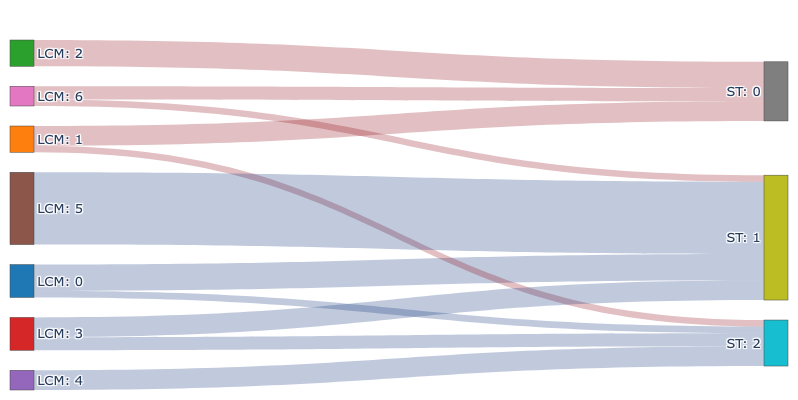

In [ ]:
#df = pd.read_csv(StringIO(raw), sep="\t", dtype={"sample": str})
df = pt_st_comparison

fig = make_alluvial(
    df,
    left_col="cluster_pt",
    right_col="cluster_st",
    sample_col="PDID",
    node_color_map=node_color_map,
    link_color_map=link_color_map,   # or None to inherit
    link_alpha=0.25,                 # transparency for inherited link colors
    title=" ",
)

fig.update_layout(width=250, height=400)

fig.show()
fig.write_image("../data/LCM_ST_comparison/AT3/AT3_alluvial_cluster_plot_resub2.pdf", 
                format="pdf", width=250, height=400, scale=1)

# Phenotype comparisons (Pyclone - pairtree)

In [ ]:
# Colours - cell class
class_colours = {'AC-gliosis-hypoxia':'#B37029', 'Neuron-like':'#CCCACB', 
             'OPC-NPC-like':'#DBDD8C', 'Proliferative':'#3DBDED'}

# Colours - niches
niche_colours = {
    "Immune (TAMs)": "#8B4513",
    "Dev-like (AC)": "#E0B84F",
    "Grey matter": "#66C2FF",
    "Gliosis (diffuse)": "#C4B7DB",
    "White matter": "#4B0082",
    "Hypoxic 1 (niche)": "#555555",
    "Gliosis": "#CD6633",
    "Vasculature": "#009E73",
    "Immune (resident)": "#3B5BA5",
    "Dev-like (OPC)": "#F4C288",
    "Proliferative": "#ebe363",
    "Gliosis transition": "#B03060",
    "Pial layer": "#C0C0C0",
    "Astrocyte rich": "#4DAF4A"
}

## Pairtree-pyclone dists

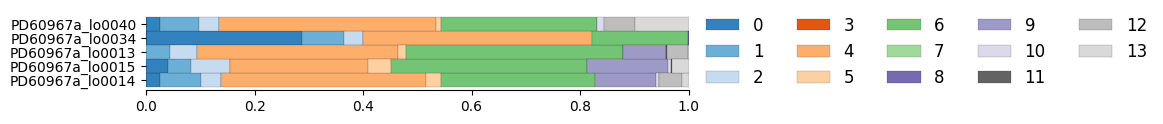

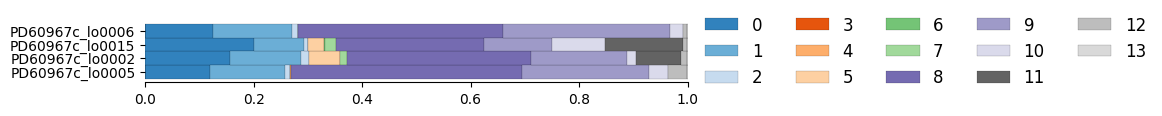

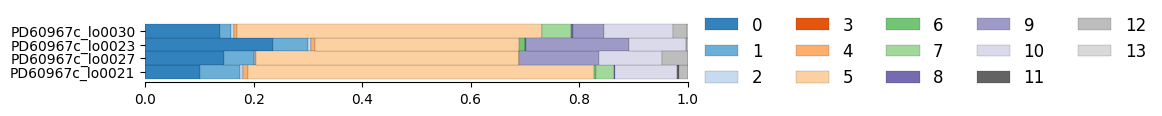

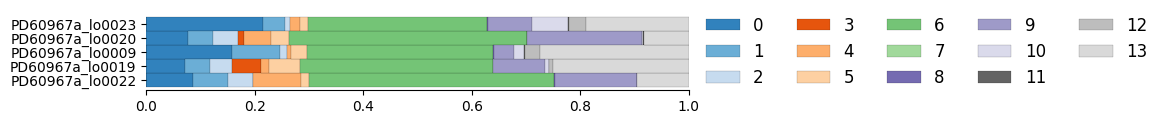

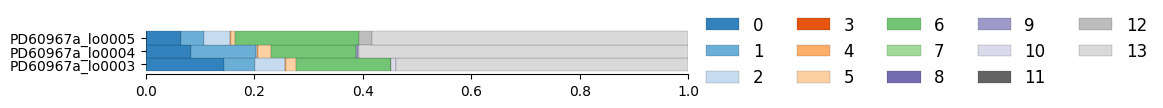

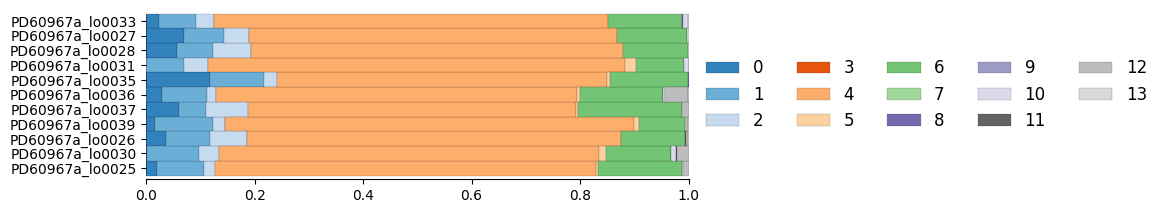

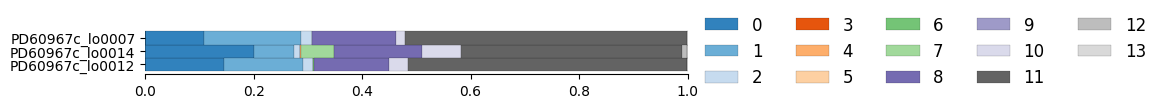

In [ ]:
# save each cluster as its own bar plots
pt_df = pt_df.transpose()[pt_cluster_ids['PDID']].transpose()

col_width = 7/len(pt_df.index)

for cluster in np.unique(pt_cluster_ids['cluster']):
    cluster_PDIDs = pt_cluster_ids[pt_cluster_ids['cluster']==cluster]['PDID'].tolist()
    pt_df_cluster = pt_df[pt_df.index.isin(cluster_PDIDs)]

    fig, ax = plt.subplots(figsize=(7,col_width*len(cluster_PDIDs)))         # Sample figsize in inches
    pt_df_cluster.plot.barh(stacked=True, width=1, ax = ax, 
                    cmap = 'tab20c', edgecolor='black', linewidth=0.1)
    ax.margins(x=0)
    
    ax.legend(
        loc="center left",           # anchor legend's left side…
        bbox_to_anchor=(1.02, 0.5),  # …to a point just outside the right edge (x>1)
        borderaxespad=0.0,
        fontsize=12,
        frameon=False,
        ncol=5
    )
    
    ax.spines['bottom'].set_visible(True)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.savefig('../data/LCM_ST_comparison/AT3/PDID_cluster_clones_{}_resub.pdf'.format(str(cluster)))

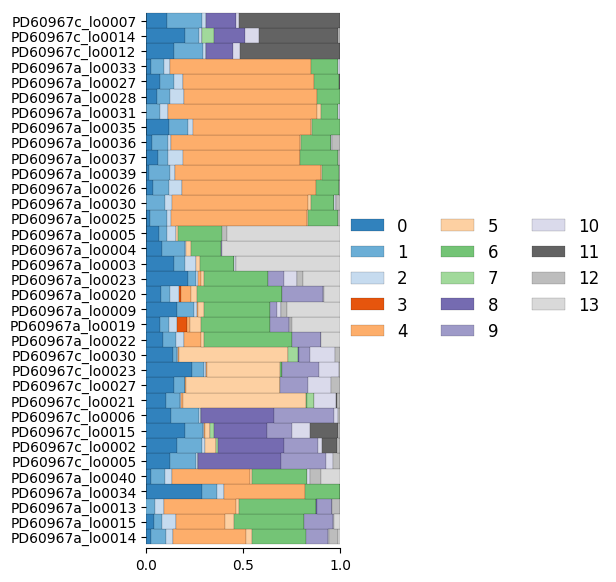

In [ ]:
fig, ax = plt.subplots(figsize=(2.5,7))         # Sample figsize in inches
pt_df.plot.barh(stacked=True, width=1, ax = ax, 
                cmap = 'tab20c', edgecolor='black', linewidth=0.1)
ax.margins(x=0)

ax.legend(
    loc="center left",           # anchor legend's left side…
    bbox_to_anchor=(1.02, 0.5),  # …to a point just outside the right edge (x>1)
    borderaxespad=0.0,
    fontsize=12,
    frameon=False,
    ncol=3
)

ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)


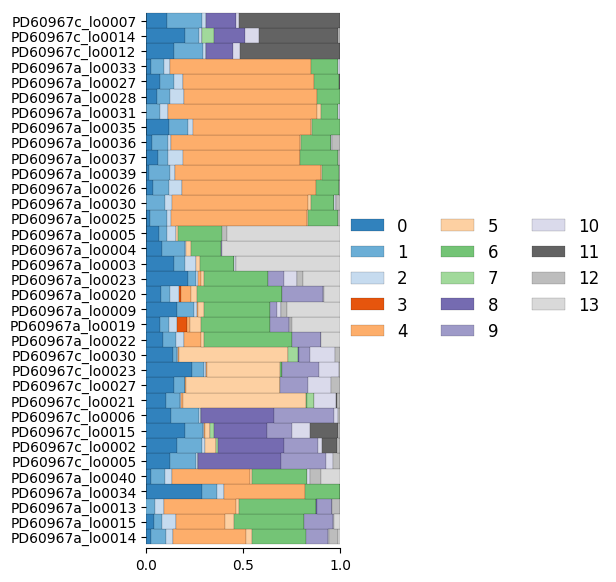

In [ ]:
pt_df = pt_df.transpose()[pt_cluster_ids['PDID']].transpose()

fig, ax = plt.subplots(figsize=(2.5,7))         # Sample figsize in inches
pt_df.plot.barh(stacked=True, width=1, ax = ax, 
                cmap = 'tab20c', edgecolor='black', linewidth=0.1)
ax.margins(x=0)

ax.legend(
    loc="center left",           # anchor legend's left side…
    bbox_to_anchor=(1.02, 0.5),  # …to a point just outside the right edge (x>1)
    borderaxespad=0.0,
    fontsize=12,
    frameon=False,
    ncol=3
)

ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)


## Cell states

In [ ]:
# cell class dataframe
level_state = 'cell_class'
malignant_cells = sorted(set(annotation_hierarchy[annotation_hierarchy['TME_GBM_granular'].str.contains('like')][level_state]))

states_per_pdid = []
for section in slides:
    id_df = slides[section].obs[['PDID']]
    ct_df = extract_feature(slides[section], 'Cell state abundances').fillna(0)

    ct_df = pd.merge(id_df.reset_index(), ct_df.reset_index(), on = 'index').dropna()
    ct_df = ct_df.drop('index', axis=1).groupby('PDID').sum()
    ct_df = merge_granular_states(ct_df, 'cell_class')

    #ct_df = ct_df.divide(ct_df.sum(axis=1), axis=0) - focus on malignant

    states_per_pdid.append(ct_df)
states_per_pdid = pd.concat(states_per_pdid).fillna(0)

# malignant only
states_per_pdid = states_per_pdid[['AC-gliosis-hypoxia', 'Neuron-like', 'Proliferative', 'OPC-NPC-like']]
states_per_pdid = states_per_pdid.divide(states_per_pdid.sum(axis=1), axis=0)


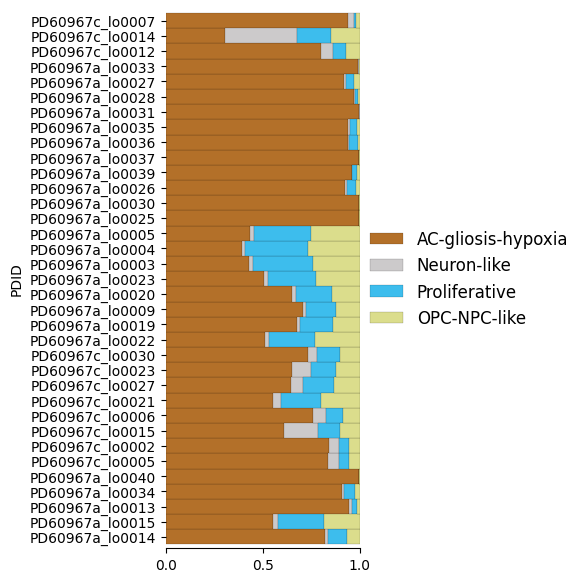

In [ ]:
states_per_pdid = states_per_pdid.transpose()[pt_cluster_ids['PDID']].transpose()

fig, ax = plt.subplots(figsize=(2.5,7))         # Sample figsize in inches
states_per_pdid.plot.barh(stacked=True, width=1, ax = ax,
                color = class_colours, edgecolor='black', linewidth=0.1)
ax.margins(x=0)

ax.legend(
    loc="center left",           # anchor legend's left side…
    bbox_to_anchor=(1.02, 0.5),  # …to a point just outside the right edge (x>1)
    borderaxespad=0.0,
    fontsize=12,
    frameon=False,
    ncol=1
)

ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('../data/LCM_ST_comparison/AT3/PDID_cluster_states_resub.pdf')

## Niches

In [ ]:
niches_per_pdid = []
for section in slides:
    id_df = slides[section].obs[['PDID']]
    sn_df = extract_feature(slides[section], 'Spatial niche abundances')

    sn_df = pd.merge(id_df.reset_index(), sn_df.reset_index(), on = 'index').dropna()
    sn_df = sn_df.drop('index', axis=1).groupby('PDID').sum().fillna(0)
    sn_df = sn_df.divide(sn_df.sum(axis=1), axis=0)
    niches_per_pdid.append(sn_df)
niches_per_pdid = pd.concat(niches_per_pdid).fillna(0)

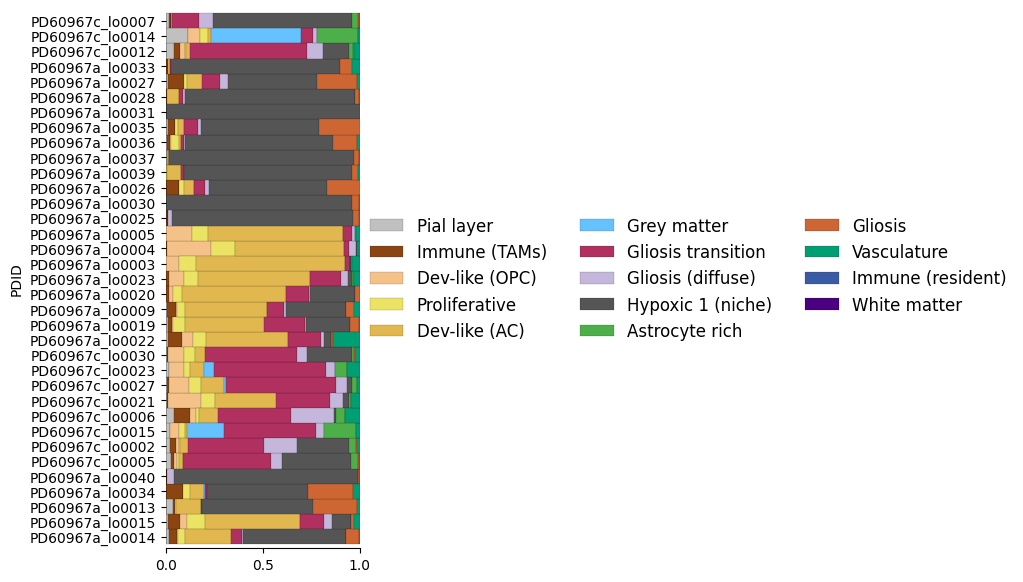

In [ ]:
niches_per_pdid = niches_per_pdid.transpose()[pt_cluster_ids['PDID']].transpose()

fig, ax = plt.subplots(figsize=(2.5,7))         # Sample figsize in inches
niches_per_pdid.plot.barh(stacked=True, width=1, ax = ax,
                color = niche_colours, edgecolor='black', linewidth=0.1)
ax.margins(x=0)

ax.legend(
    loc="center left",           # anchor legend's left side…
    bbox_to_anchor=(1.02, 0.5),  # …to a point just outside the right edge (x>1)
    borderaxespad=0.0,
    fontsize=12,
    frameon=False,
    ncol=3
)

ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('../data/LCM_ST_comparison/AT3/PDID_cluster_niches_resub.pdf')

# Section maps

## Pairtree

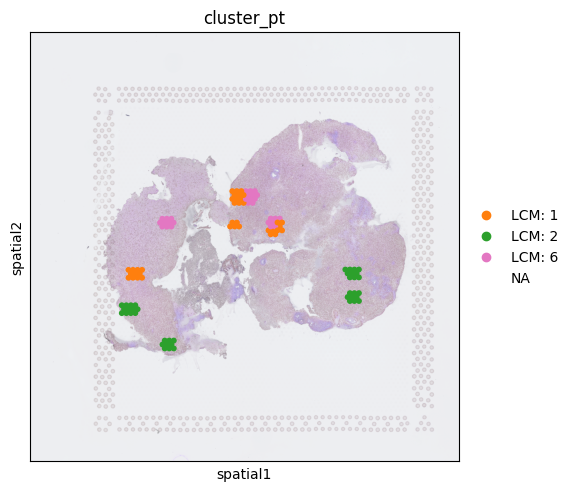

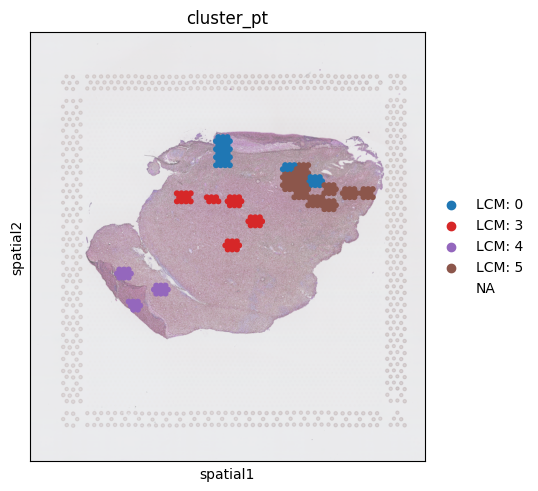

In [ ]:
for section in slides:
    if donor in section:
        clusters = sorted(list(set(pt_st_comparison['cluster_pt'])))
        clusters = [i for i in clusters if i in slides[section].obs['cluster_pt'].tolist()]
        cluster_cols = [node_color_map[i] for i in clusters]

        slides[section].uns['cluster_pt_colors'] = cluster_cols

        sq.pl.spatial_scatter(slides[section], color = 'cluster_pt', size = 2, img_alpha = 0.6)
        plt.savefig('../data/LCM_ST_comparison/AT3/PT_section_{}_resub.png'.format(section), dpi=300)

## SpaceTree

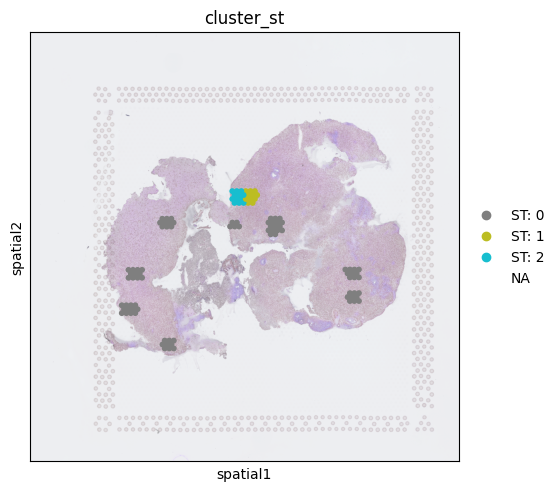

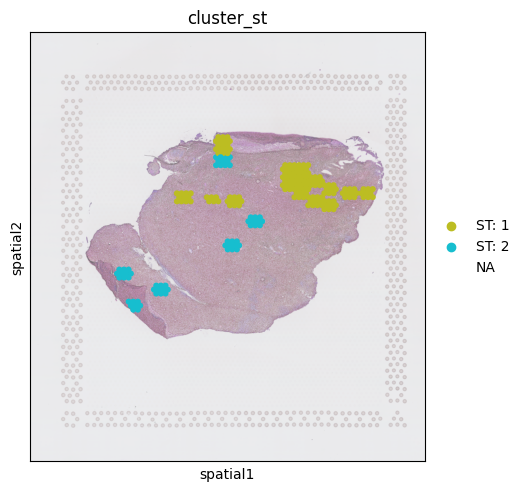

In [ ]:
for section in slides:
    if donor in section:
        clusters = sorted(list(set(pt_st_comparison['cluster_st'])))
        clusters = [i for i in clusters if i in slides[section].obs['cluster_st'].tolist()]
        cluster_cols = [node_color_map[i] for i in clusters]

        slides[section].uns['cluster_st_colors'] = cluster_cols

        sq.pl.spatial_scatter(slides[section], color = 'cluster_st', size = 2, img_alpha = 0.6)
        plt.savefig('../data/LCM_ST_comparison/AT3/ST_section_{}_resub.png'.format(section), dpi=300)

# Pairtree clone composition

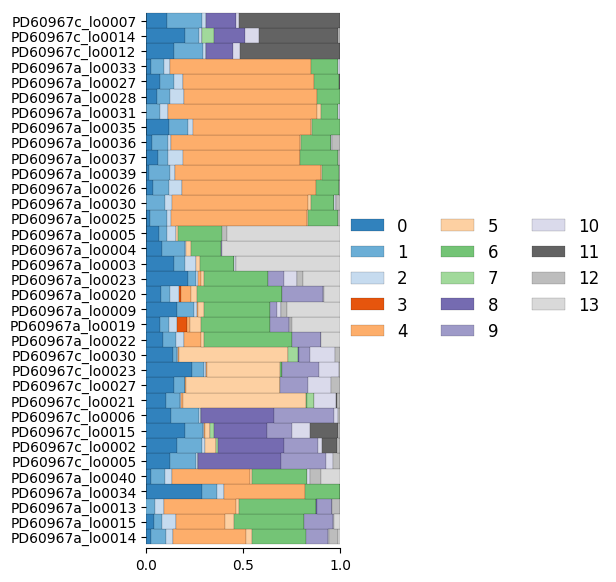

In [ ]:
pt_df = pt_df.transpose()[pt_cluster_ids['PDID']].transpose()

fig, ax = plt.subplots(figsize=(2.5,7))         # Sample figsize in inches
pt_df.plot.barh(stacked=True, width=1, ax = ax, 
                cmap = 'tab20c', edgecolor='black', linewidth=0.1)
ax.margins(x=0)

ax.legend(
    loc="center left",           # anchor legend's left side…
    bbox_to_anchor=(1.02, 0.5),  # …to a point just outside the right edge (x>1)
    borderaxespad=0.0,
    fontsize=12,
    frameon=False,
    ncol=3
)

ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [ ]:
pt_df.to_csv('../../../data/Fig4/Fig4e_pyclone_compositions.csv')